In [1]:
from typing import Tuple, List

import os
import rootutils

rootutils.setup_root(os.path.abspath('./'), indicator=".project-root", pythonpath=True, dotenv=True, cwd=True)

# auto-loading of imports from outside scripts
%load_ext autoreload
%autoreload 2

In [2]:
!touch test.py

In [3]:
from src.utils import create_df, compute_fingerprints, compute_descriptors, create_data, eval_metrics, plot_pred_true, plot_importance
from src.avail_descriptors import descriptors_all, descriptors_short

In [4]:
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from argparse import Namespace

from sklearn.model_selection import train_test_split

---
# Feature Extraction:

In [5]:
bradley_path = "data/Bradley_dataset_ok_3"
pubchem_path = "data/pubchem"
chembook_path = "data/chembook"

columns_bradley = ['line_number', 'smiles', 'cas', 'label', 'T']
df_bradley = create_df(bradley_path, columns_bradley)

columns_pubchem = ['line_number', 'smiles', 'label', 'T']
df_pubchem = create_df(pubchem_path, columns_pubchem)

columns_chembook = ['line_number', 'smiles', 'label', 'T']
df_chembook = create_df(chembook_path, columns_chembook)


In [6]:
data_args = {
    "descriptors": descriptors_all,

    "apply_norm": False,    # not applying norm, because of data leakage
    
    "create_fingerprints": False,
    "temp_column": True,
}

### Computing Features (load, if already precomputed)

In [7]:
from src.utils import create_or_load_data

In [8]:
X_bradley, labels_bradley, temp_bradley = create_or_load_data(df_bradley, data_args, 'saved_np_obj/Bradley', load_data=True)

Loading data from saved_np_obj/Bradley


In [9]:
# Pubchem Temperatures are all NaNs, there are no temperatures for pubchem dataset
X_pubchem, labels_pubchem, temp_pubchem = create_or_load_data(df_pubchem, data_args, 'saved_np_obj/pubchem', load_data=True)

Loading data from saved_np_obj/pubchem


In [10]:
X_chembook, labels_chembook, temp_chembook = create_or_load_data(df_chembook, data_args, 'saved_np_obj/chembook', load_data=True)

Loading data from saved_np_obj/chembook


In [11]:
X = np.concatenate([X_bradley, X_pubchem, X_chembook])
labels = np.concatenate([labels_bradley, labels_pubchem, labels_chembook])
temp = np.concatenate([temp_bradley, temp_pubchem, temp_chembook])

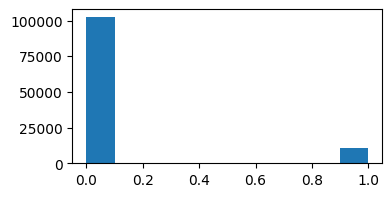

In [12]:
plt.figure(figsize=(4, 2))
plt.hist(labels)
None

---

## Use Over-Sampling for minority class

In [13]:
from src.utils import perform_smote

In [14]:
X, labels, temp = perform_smote(X, labels, temp)

---
# MultiTask Learning with Lightning:

In [15]:
from src.multitask_nn import MultiTaskModel, create_datasets

from lightning.pytorch.callbacks import Callback, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from lightning import seed_everything, Trainer
from torch.utils.data import DataLoader

from datetime import datetime

In [16]:
seed_everything(42, verbose=False)

42

In [17]:
cfg = Namespace(
    project_name="pubchem_bradley",
    
    normalize_data=True,
    train_size=0.8,

    batch_size=512,
    lr=1e-3,
    max_epochs=20,

    hid_dim=256,
    depth=4,
    use_residual=True,
    drop=0.2,

    cl_loss_coef=1.,
    pos_label_weight=1,

    reg_loss_coef=10e-4,

    num_workers=0,
    persistent_workers=False,
)

In [18]:
train_data, val_data = create_datasets(X, labels, temp, use_norm=cfg.normalize_data, train_size=cfg.train_size)

# persistent_workers=True reduces overhead of creating workers
train_loader = DataLoader(train_data, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, persistent_workers=cfg.persistent_workers)
val_loader = DataLoader(val_data, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, persistent_workers=cfg.persistent_workers)

In [19]:
input_dim = X.shape[1]
model = MultiTaskModel(
    input_dim=input_dim,

    hidden_dim=cfg.hid_dim,
    depth=cfg.depth,
    use_residual=cfg.use_residual,
    drop=cfg.drop,

    lr=cfg.lr,

    cl_loss_coef=cfg.cl_loss_coef,
    reg_loss_coef=cfg.reg_loss_coef
)

current_date = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

logger = TensorBoardLogger(
    save_dir="tb_logs/", name=cfg.project_name
)

checkpoint_callback = ModelCheckpoint(
    dirpath=f"checkpoints/{cfg.project_name}-{current_date}",
    filename="{epoch:02d}-{val_loss:.4f}",
    save_top_k=1,
    monitor="V_tot",
    mode="min",
    save_last=False,
)

trainer = Trainer(
    logger=logger,
    callbacks=[checkpoint_callback],
    max_epochs=cfg.max_epochs,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [20]:
trainer.fit(model, train_loader, val_loader)


  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | shared       | Sequential        | 223 K  | train
1 | classifier   | Sequential        | 66.0 K | train
2 | regressor    | Sequential        | 66.0 K | train
3 | val_accuracy | BinaryAccuracy    | 0      | train
4 | val_f1       | BinaryF1Score     | 0      | train
5 | val_roc_auc  | BinaryAUROC       | 0      | train
6 | val_r2_class | R2Score           | 0      | train
7 | val_mse      | MeanSquaredError  | 0      | train
8 | val_mae      | MeanAbsoluteError | 0      | train
9 | val_r2_reg   | R2Score           | 0      | train
-----------------------------------------------------------
355 K     Trainable params
0         Non-trainable params
355 K     Total params
1.421     Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/avarlamov/phase-prediction/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/avarlamov/phase-prediction/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

---
# Plotting predictions:

In [260]:
from src.plot_utils import plot_T_from_distance_for_nn

Computing T(distance) plot: 100%|██████████| 161/161 [00:01<00:00, 95.44it/s] 


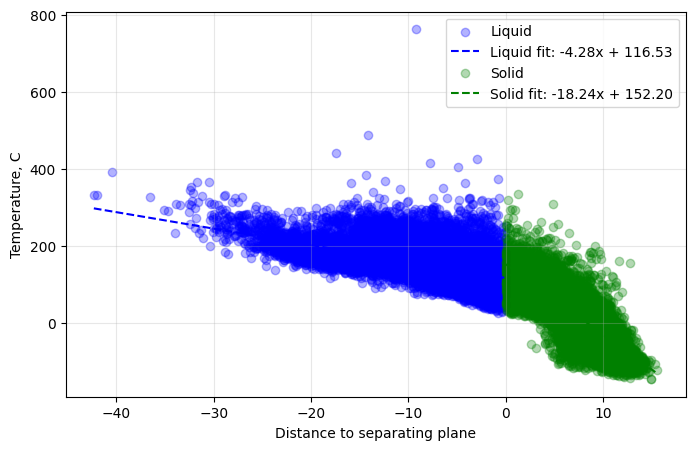

In [276]:
plot_T_from_distance_for_nn(model, val_loader)

---
## Comparing with catboost:

In [262]:
raise Exception("stop")

Exception: stop

In [189]:
from catboost import CatBoostClassifier, CatBoostRegressor
from src.utils import eval_metrics

In [210]:
X_train, X_val, y_train, y_val, temp_train, temp_val = train_test_split(X, labels, temp, train_size=0.3)

In [ ]:
catboost_reg = CatBoostRegressor(
    verbose=100,
)

catboost_reg.fit(X_train[~np.isnan(temp_train)], temp_train[~np.isnan(temp_train)])
temp_pred = catboost_reg.predict(X_val[~np.isnan(temp_val)])

Learning rate set to 0.053248
0:	learn: 94.1515284	total: 3.29ms	remaining: 3.28s
100:	learn: 46.9774857	total: 191ms	remaining: 1.7s
200:	learn: 44.0075059	total: 373ms	remaining: 1.48s
300:	learn: 41.2073333	total: 573ms	remaining: 1.33s
400:	learn: 39.2678277	total: 793ms	remaining: 1.18s
500:	learn: 37.5712661	total: 994ms	remaining: 990ms
600:	learn: 36.0912636	total: 1.19s	remaining: 787ms
700:	learn: 34.8666691	total: 1.37s	remaining: 586ms
800:	learn: 33.7864749	total: 1.56s	remaining: 388ms
900:	learn: 32.6599576	total: 1.78s	remaining: 196ms
999:	learn: 31.6815817	total: 1.98s	remaining: 0us


In [212]:
eval_metrics(temp_val[~np.isnan(temp_val)], temp_pred, type="regression")

{'MSE': 1891.2296764890668, 'MAE': 32.09461103606893, 'R2': 0.8041789833247583}

In [213]:
catboost_cl = CatBoostClassifier(
   verbose=100,
)

catboost_cl.fit(X_train, y_train)
y_pred = catboost_cl.predict(X_val)

Learning rate set to 0.050352
0:	learn: 0.6094294	total: 26.4ms	remaining: 26.4s
100:	learn: 0.0978030	total: 1.13s	remaining: 10.1s
200:	learn: 0.0763545	total: 2.23s	remaining: 8.86s
300:	learn: 0.0657813	total: 3.34s	remaining: 7.76s
400:	learn: 0.0586442	total: 4.43s	remaining: 6.62s
500:	learn: 0.0543040	total: 5.45s	remaining: 5.43s
600:	learn: 0.0507741	total: 6.47s	remaining: 4.29s
700:	learn: 0.0474602	total: 7.5s	remaining: 3.2s
800:	learn: 0.0446874	total: 8.71s	remaining: 2.16s
900:	learn: 0.0425495	total: 9.94s	remaining: 1.09s
999:	learn: 0.0413354	total: 11.1s	remaining: 0us


In [ ]:
eval_metrics(y_val, y_pred, type="classification")

{'ACC': 0.9788045627376426,
 'F1': 0.9789671951028096,
 'BAL-ACC': 0.9787944751719893,
 'ROC-AUC': 0.9787944751719894,
 'R2': 0.9152180205038125}

### Regression on distance to plane:

- training and testing on data, that was not used for training of classifier

In [223]:
X_dist_train, X_dist_val, temp_dist_train, temp_dist_val = train_test_split(X_val[~np.isnan(temp_val)], temp_val[~np.isnan(temp_val)], train_size=0.8)

In [224]:
dist_train = catboost_cl.predict(X_dist_train, prediction_type="RawFormulaVal").reshape(-1, 1)
dist_val = catboost_cl.predict(X_dist_val, prediction_type="RawFormulaVal").reshape(-1, 1)

In [ ]:
reg_on_dist = CatBoostRegressor(
    verbose=200,
)

reg_on_dist.fit(dist_train, temp_dist_train)
temp_dist_pred = reg_on_dist.predict(dist_val)

Learning rate set to 0.063682
0:	learn: 94.0634838	total: 2.14ms	remaining: 2.14s
200:	learn: 51.3933130	total: 312ms	remaining: 1.24s
400:	learn: 51.1849013	total: 628ms	remaining: 938ms
600:	learn: 51.1030792	total: 938ms	remaining: 623ms
800:	learn: 51.0633440	total: 1.24s	remaining: 309ms
999:	learn: 51.0429712	total: 1.55s	remaining: 0us


In [269]:
from src.plot_utils import plot_T_from_distance_for_catboost
from src.utils import plot_pred_true

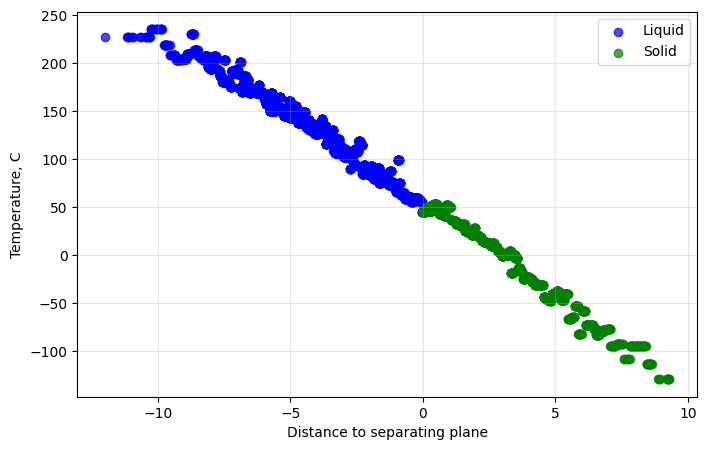

In [275]:
plot_T_from_distance_for_catboost(temp_dist_pred, dist_val)

In [ ]:
eval_metrics(temp_dist_val, temp_dist_pred, type="regression")

{'MSE': 2694.400092845229, 'MAE': 38.949095827109105, 'R2': 0.7185756133559936}